## TS7: Filtrado digital lineal de ECG
Catalina Wynne 

### Consigna:
Usando el archivo ecg.mat que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas a continuación. Diseñe y aplique los filtros digitales necesarios para mitigar las siguientes fuentes de contaminación:


Ruido causado por el movimiento de los electrodos (Alta frecuencia).
Ruido muscular (Alta frecuencia).
Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).
Ayuda: Los detalles de cómo acceder a ecg.mat los pueden encontrar en lectura_sigs.py

Archivo ECG.mat
(variables)

ecg_lead: Registro de ECG muestreado a 
fs=1kHz durante una prueba de esfuerzo
qrs_pattern1: Complejo de ondas QRS normal
heartbeat_pattern1: Latido normal
heartbeat_pattern2: Latido de origen ventricular
qrs_detections: vector con las localizaciones (en # de muestras) donde ocurren los latidos

Se pide:


a) Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a  suavidad de los trazos y nivel isoeléctrico nulo.

Ayuda: Utilice los resultados del ancho de banda estimado del ECG en la Tarea Semanal 5. Tome como referencia las siguientes morfologías promedio para evaluar cualitativamente la efectividad de los filtros diseñados.
 
b) ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

c) Diseñe al menos dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

Ayuda: Para los filtros IIR adopte las aproximaciones de módulo de máxima planicidad, Chebyshev y Cauer. Para los FIR, utilice las metodologías de ventanas, cuadrados mínimos y Parks-Mc Clellan-Remez. Todos implementados en SciPy.Signal

d)  Evalúe el rendimiento de los filtros que haya diseñado:

Verifique que filtra las señales interferentes.
Verifique que es inocuo en las zonas donde no hay interferentes.
Ayuda: Utilice el siguiente código como referencia para analizar los puntos 1 y 2). También puede incluir otras regiones que considere de interés.

Bonus:
💎 Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

## Introducción
En este trabajo se tuvo como objetivo diseñar, implementar y evaluar como trabajan diversos filtros estudiados en clase.
Los filtros utilizados fueron del tipo FIR y del tipo IIR, para los primeros se llevo a cabo el trabajo con Ventana con firwin2, se utilizó el método de cuadrados mínimos y finalmente,  Remez. Para los filtros IIR se usó Chebishev tipo 1 y Cauer


### Librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig 
import scipy.io as sio  
import matplotlib.patches as patches
import matplotlib.lines as mlines


### Carga del ECG y parámetros para la plantilla 

In [2]:
fs = 1000
mat_struct = sio.loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()

# Esta es la plantilla teórica
ws1_teorica = 0.2   
wp1_teorica = 1.2   
wp2_teorica = 35.0  
ws2_teorica = 36.0  
gpass = 1
gstop = 40
ripple = 1
'RETARDO DE GRUPO'
ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500), 
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs//2, num=50)]) 
# Elementos comunes para las leyendas de las plantillas
green_patch = patches.Patch(color='#ccebd5', label='bw digital')
dashed_line = mlines.Line2D([], [], color='none', markeredgecolor='black', marker='s', markersize=15, markeredgewidth=1.2, linestyle='--', label='plantilla')

# Regiones de interés temporales
regs_sin_ruido = ([4000, 5500], [10000, 11000])
regs_con_ruido = (
    np.array([5, 5.2]) * 60 * fs, # Muestras 300000 a 312000
    np.array([12, 12.4]) * 60 * fs, # Muestras 720000 a 744000
    np.array([15, 15.2]) * 60 * fs # Muestras 900000 a 912000
)

## Definición de la plantilla de diseño
El objetivo es obtener una señal ECG libre de las principales fuentes de interferencia.

Se consideró como banda útil del ECG el rango comprendido aproximado entre 1 Hz y 35 Hz.

Partiendo de esto se estableció una plantilla pasabanda con estos parámetros:

Banda de rechazo inferior 0-0.2 Hz

Banda de paso: 1.2-35 Hz

Banda de rechazo superior: mayor a 36 Hz

Ripple: 1 dB

Atenuación mínima: 40 dB

La plantilla fue obtenida a partir del análisis espectral realizado en la TS5.

Se observó que la mayor parte de concentración de la energía está por debajo de los 35 Hz.

Con el fin de preservar la funcionalidad del latido y eliminar las interferencias más relevantes, se utilizó un pasabanda entre 1 y 35 Hz.

Los valores utilizados en cada filtro se obtuvieron a prueba y error, se fueron cambiando las bandas y los pesos, según se observaba en la plantilla al visualizarla.

### Filtro Butter de referencia 

Orden Butterworth: 348


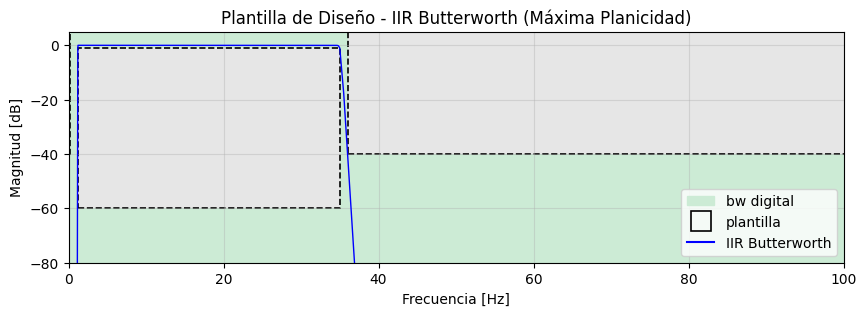

--- COMPARACIONES TEMPORALES: IIR BUTTERWORTH (ZONAS SIN RUIDO) ---


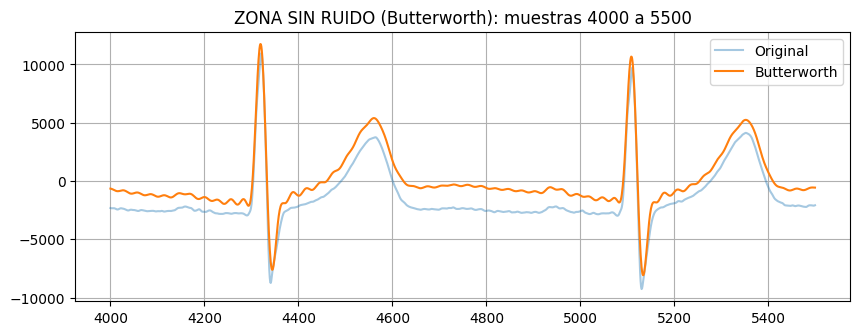

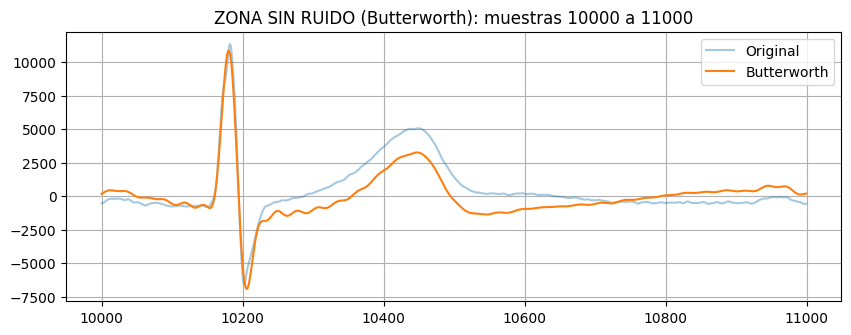

--- COMPARACIONES TEMPORALES: IIR BUTTERWORTH (ZONAS CON RUIDO) ---


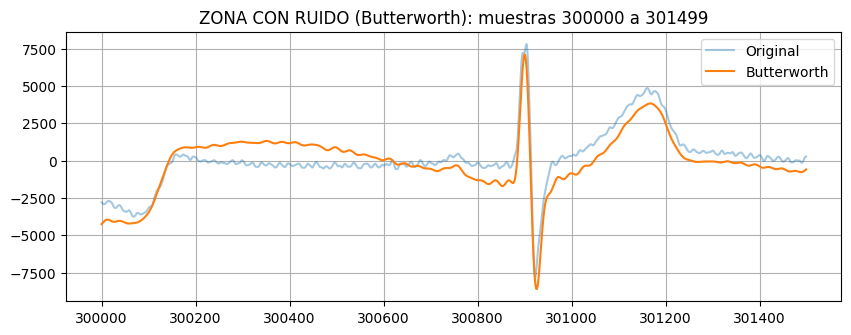

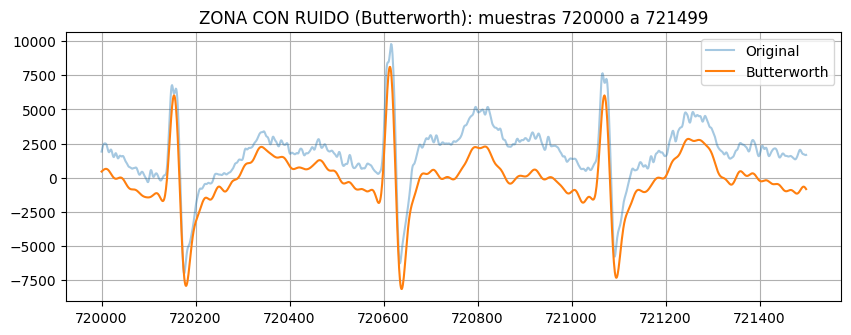

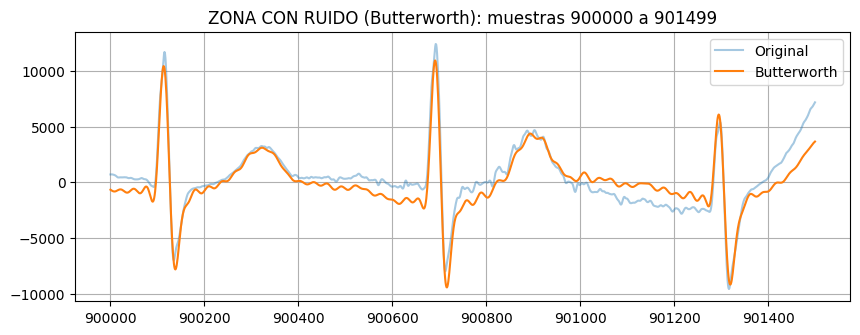

In [3]:
sos_butt = sig.iirdesign(
    wp=[wp1_teorica, wp2_teorica], ws=[ws1_teorica, ws2_teorica], gpass=gpass, gstop=gstop,
    fs=fs, output='sos', ftype='butter'
)
ecg_butt = sig.sosfiltfilt(sos_butt, ecg_one_lead)
print(f"Orden Butterworth: {len(sos_butt) * 2}")
# --- Plantilla Espectral Butterworth ---
w, h = sig.sosfreqz(sos_butt, worN=ww, fs=fs)
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_facecolor('#ccebd5')
ax.add_patch(patches.Rectangle((0, -gstop), ws1_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((wp1_teorica, -60), wp2_teorica - wp1_teorica, (-ripple) - (-60), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((ws2_teorica, -gstop), (fs/2) - ws2_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), color='blue', linewidth=1)
ax.set_title('Plantilla de Diseño - IIR Butterworth (Máxima Planicidad)')
ax.set_xlabel('Frecuencia [Hz]'); ax.set_ylabel('Magnitud [dB]')
ax.grid(True, linestyle='-', alpha=0.4); ax.set_xlim([0, 100]); ax.set_ylim([-80, 5])
ax.legend(handles=[green_patch, dashed_line, mlines.Line2D([], [], color='blue', label='IIR Butterworth')], loc='lower right')
plt.show()

# --- Gráficos Temporales (Zonas SIN Ruido) ---
print("--- COMPARACIONES TEMPORALES: IIR BUTTERWORTH (ZONAS SIN RUIDO) ---")
for reg in regs_sin_ruido:
    idx = np.arange(reg[0], reg[1])
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.title(f'ZONA SIN RUIDO (Butterworth): muestras {reg[0]} a {reg[1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()

# --- Gráficos Temporales (Zonas CON Ruido) ---
print("--- COMPARACIONES TEMPORALES: IIR BUTTERWORTH (ZONAS CON RUIDO) ---")
for reg in regs_con_ruido:
    idx = np.arange(int(reg[0]), int(reg[0]) + 1500)
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.title(f'ZONA CON RUIDO (Butterworth): muestras {idx[0]} a {idx[-1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()

### Filtro IIR por Chebyshev tipo 1


Orden Chebyshev I: 50


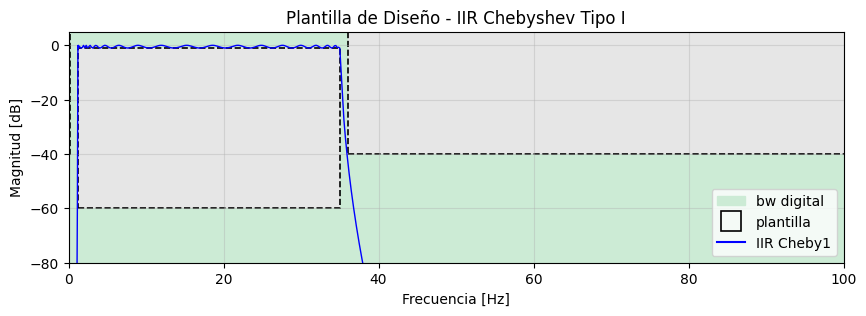

--- COMPARACIONES TEMPORALES: IIR Cheby1 ---


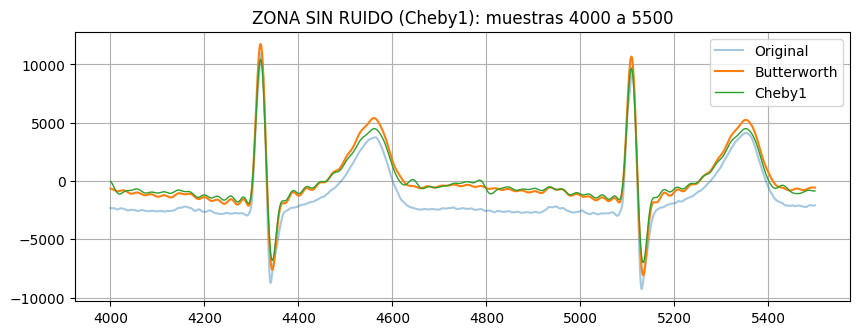

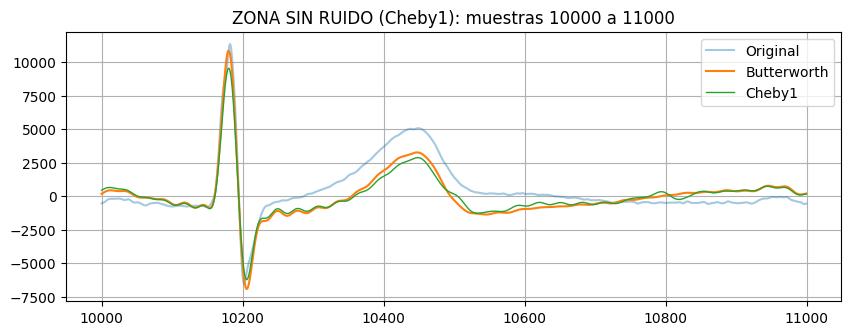

--- COMPARACIONES TEMPORALES: IIR CHEBYSHEV 1 (ZONAS CON RUIDO) ---


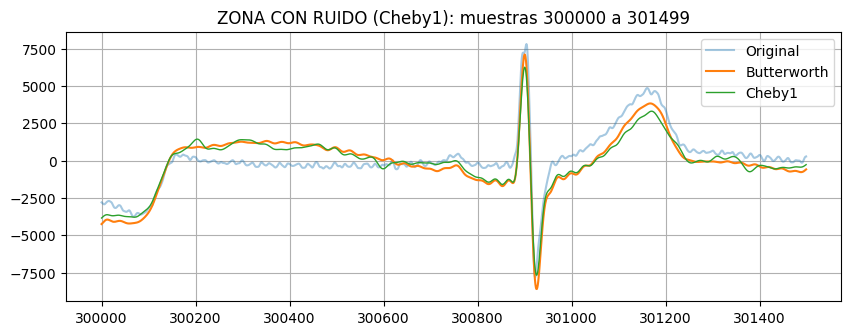

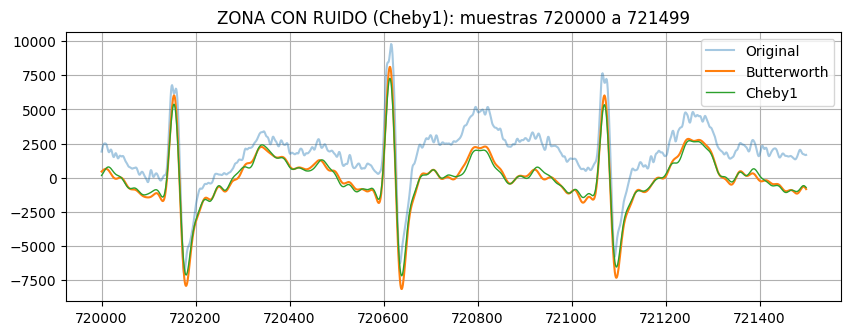

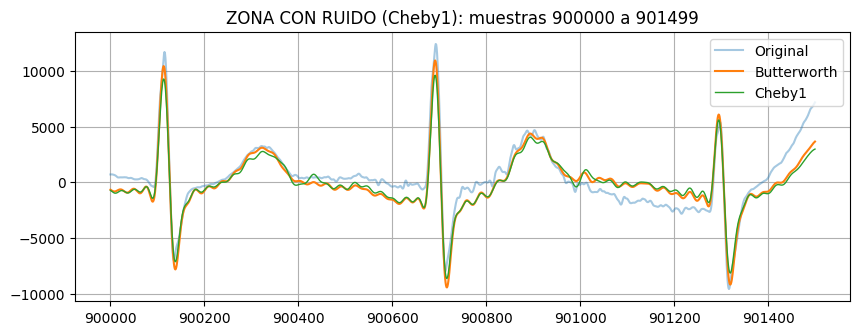

In [4]:
sos_cheby = sig.iirdesign(
    wp=[wp1_teorica, wp2_teorica], ws=[ws1_teorica, ws2_teorica], gpass=gpass, gstop=gstop,
    fs=fs, output='sos', ftype='cheby1'
)
ecg_cheby = sig.sosfiltfilt(sos_cheby, ecg_one_lead)

print(f"Orden Chebyshev I: {len(sos_cheby) * 2}")
# --- Plantilla Espectral ---
w, h = sig.sosfreqz(sos_cheby, worN=ww, fs=fs)
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_facecolor('#ccebd5') 
ax.add_patch(patches.Rectangle((0, -gstop), ws1_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((wp1_teorica, -60), wp2_teorica - wp1_teorica, (-ripple) - (-60), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((ws2_teorica, -gstop), (fs/2) - ws2_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), color='blue', linewidth=1)
ax.set_title('Plantilla de Diseño - IIR Chebyshev Tipo I')
ax.set_xlabel('Frecuencia [Hz]'); ax.set_ylabel('Magnitud [dB]')
ax.grid(True, linestyle='-', alpha=0.4); ax.set_xlim([0, 100]); ax.set_ylim([-80, 5])
ax.legend(handles=[green_patch, dashed_line, mlines.Line2D([], [], color='blue', label='IIR Cheby1')], loc='lower right')
plt.show()
# --- Gráficos Temporales ---
print("--- COMPARACIONES TEMPORALES: IIR Cheby1 ---")
for reg in regs_sin_ruido:
    idx = np.arange(reg[0], reg[1])
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_cheby[idx], label='Cheby1', linewidth=1)
    plt.title(f'ZONA SIN RUIDO (Cheby1): muestras {reg[0]} a {reg[1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()
    # --- Gráficos Temporales (Zonas CON Ruido) ---
print("--- COMPARACIONES TEMPORALES: IIR CHEBYSHEV 1 (ZONAS CON RUIDO) ---")
for reg in regs_con_ruido:
    idx = np.arange(int(reg[0]), int(reg[0]) + 1500)
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_cheby[idx], label='Cheby1', linewidth=1)
    plt.title(f'ZONA CON RUIDO (Cheby1): muestras {idx[0]} a {idx[-1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()



### Análisis
El filtro Chebyshev tipo 1 prresenta un transición más abrupta que un Butter para un mismo orden, a costa de introducir ondulaciones en la banda de paso.

La señal filtrada conserva las características principales del ECG y elimina gran parte de las interferencias presentes. Debido a la utilización de filtfilt, el desfase introducido por el filtro no afecta la señal final.

### Filtro IIR por Cauer

Orden Cauer:       16


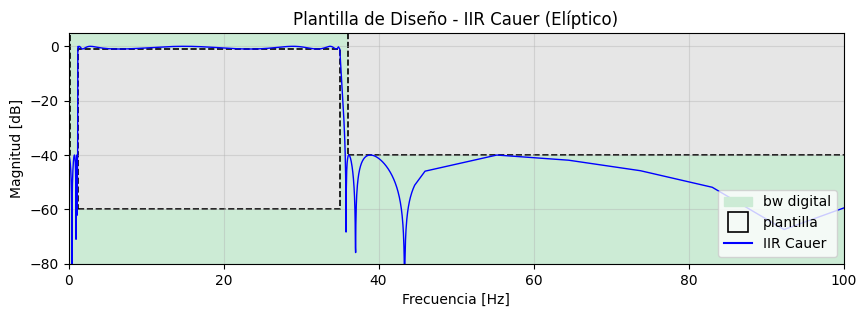

--- COMPARACIONES TEMPORALES: IIR CAUER ---


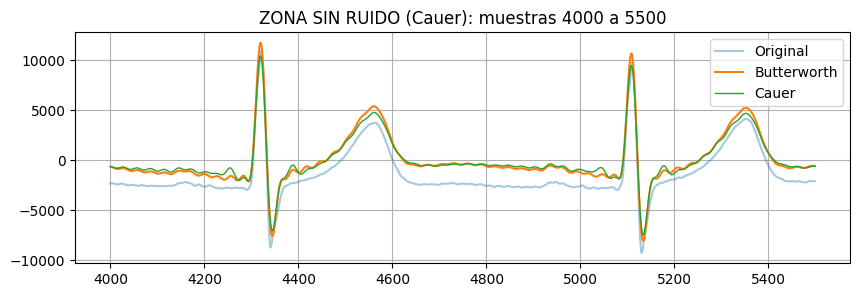

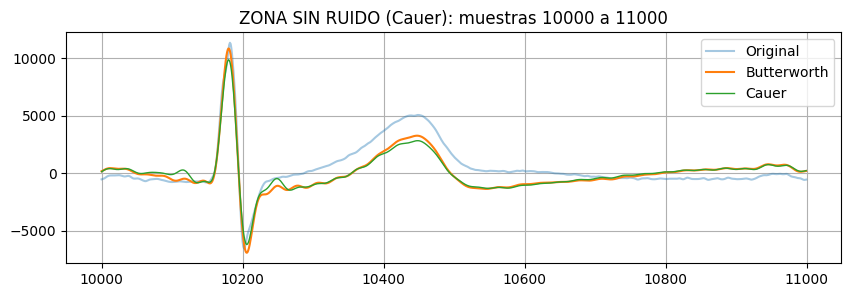

--- COMPARACIONES TEMPORALES: IIR CAUER (ZONAS CON RUIDO) ---


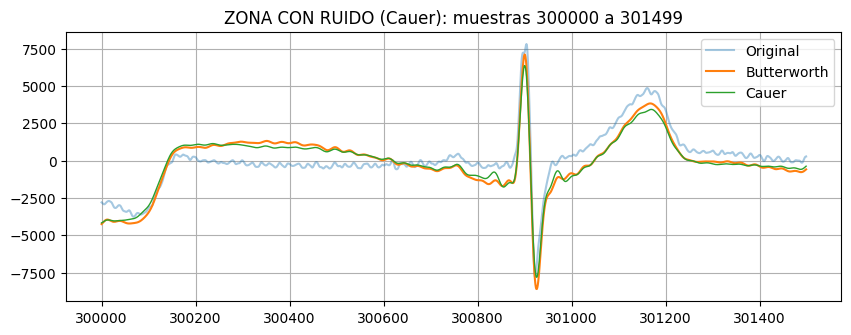

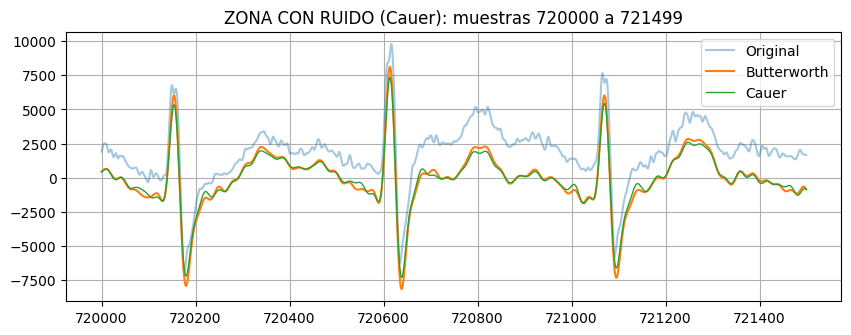

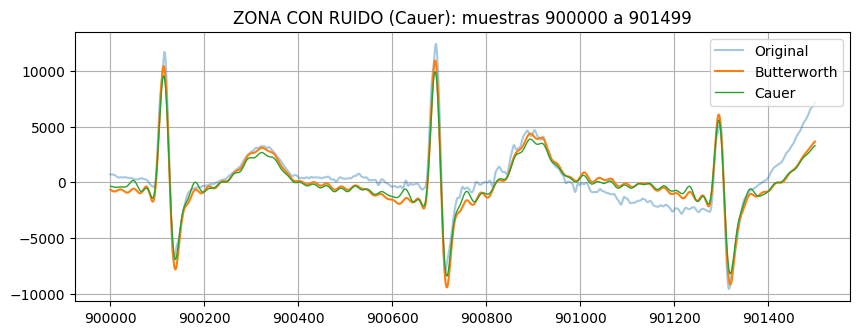

In [5]:
sos_cauer = sig.iirdesign(
    wp=[wp1_teorica, wp2_teorica], ws=[ws1_teorica, ws2_teorica], gpass=gpass, gstop=gstop,
    fs=fs, output='sos', ftype='ellip'
)
ecg_cauer = sig.sosfiltfilt(sos_cauer, ecg_one_lead)
print(f"Orden Cauer:       {len(sos_cauer) * 2}")
# --- Plantilla Espectral ---
w, h = sig.sosfreqz(sos_cauer, worN=ww, fs=fs)
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_facecolor('#ccebd5') 
ax.add_patch(patches.Rectangle((0, -gstop), ws1_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((wp1_teorica, -60), wp2_teorica - wp1_teorica, (-ripple) - (-60), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((ws2_teorica, -gstop), (fs/2) - ws2_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), color='blue', linewidth=1)
ax.set_title('Plantilla de Diseño - IIR Cauer (Elíptico)')
ax.set_xlabel('Frecuencia [Hz]'); ax.set_ylabel('Magnitud [dB]')
ax.grid(True, linestyle='-', alpha=0.4); ax.set_xlim([0, 100]); ax.set_ylim([-80, 5])
ax.legend(handles=[green_patch, dashed_line, mlines.Line2D([], [], color='blue', label='IIR Cauer')], loc='lower right')
plt.show()

# --- Gráficos Temporales ---
print("--- COMPARACIONES TEMPORALES: IIR CAUER ---")
for reg in regs_sin_ruido:
    idx = np.arange(reg[0], reg[1])
    plt.figure(figsize=(10, 3))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_cauer[idx], label='Cauer', linewidth=1)
    plt.title(f'ZONA SIN RUIDO (Cauer): muestras {reg[0]} a {reg[1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()
    # --- Gráficos Temporales (Zonas CON Ruido) ---
print("--- COMPARACIONES TEMPORALES: IIR CAUER (ZONAS CON RUIDO) ---")
for reg in regs_con_ruido:
    idx = np.arange(int(reg[0]), int(reg[0]) + 1500)
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_cauer[idx], label='Cauer', linewidth=1)
    plt.title(f'ZONA CON RUIDO (Cauer): muestras {idx[0]} a {idx[-1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()

### Análisis
El filtro Cauer tiene las transiciones más marcadas entre todos los filtros utilizados,se utilizaron ordenes relativamente bajos.
Aunque presenta ondulaciones tanto en banda de paso como de rechazo, cumple satisfactoriamente la plantilla de diseño y permite una eficiente eliminación del ruido fuera de la banda útil del ECG.


### Filtro FIR por ventana

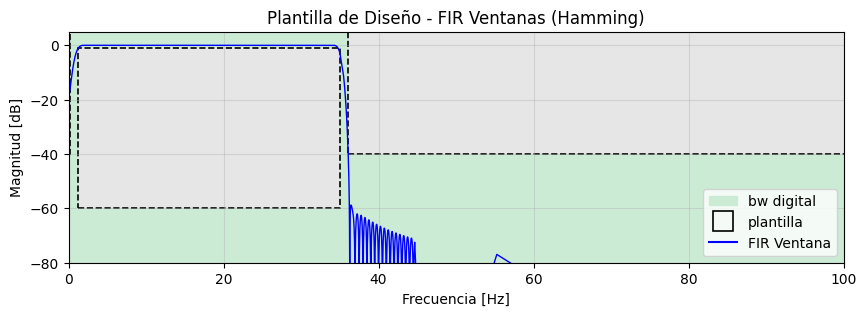

--- COMPARACIONES TEMPORALES: FIR VENTANAS (ZONAS SIN RUIDO) ---


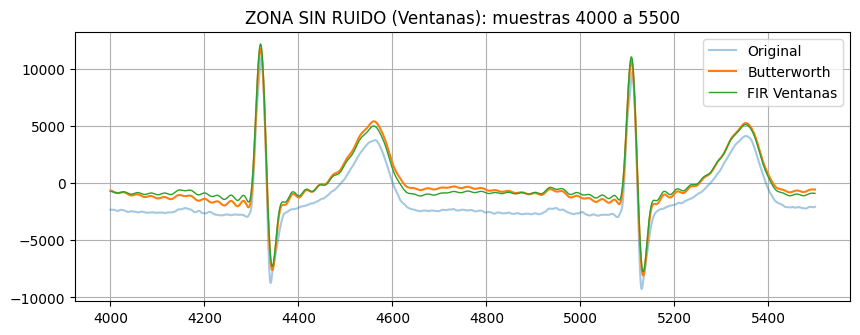

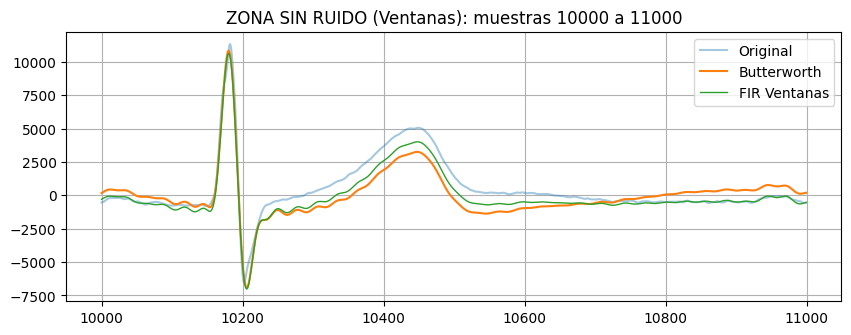

--- COMPARACIONES TEMPORALES: FIR VENTANAS (ZONAS CON RUIDO) ---


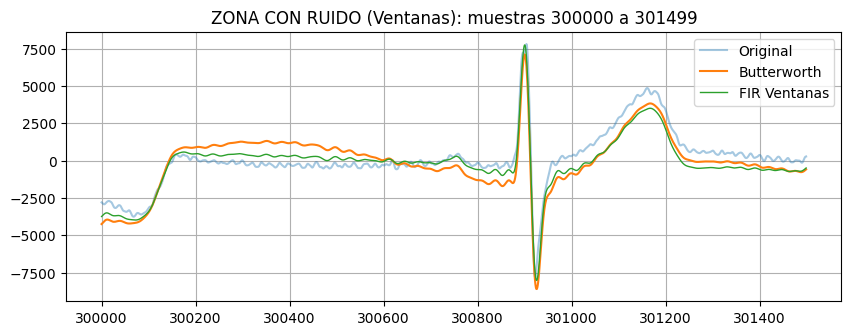

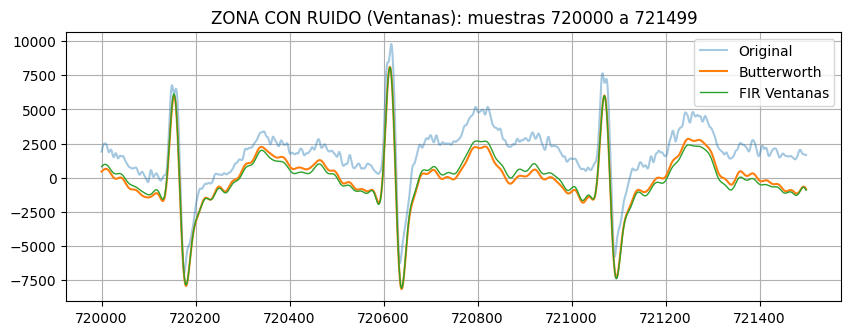

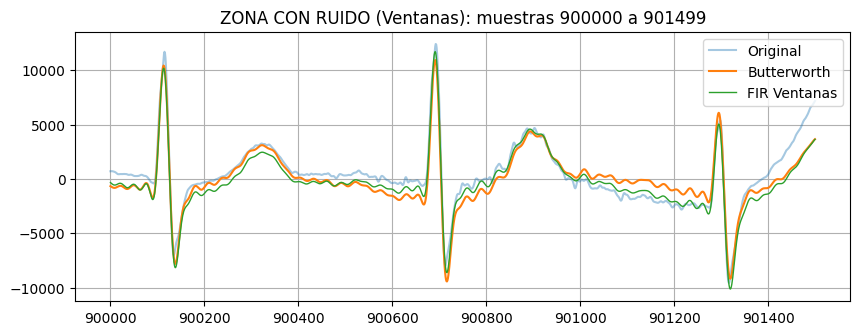

In [6]:
ws1_win = 0.2 
wp1_win = 1.2 
wp2_win = 35.0 
ws2_win = 35.5 
numtaps_win = 2000
gains_win = [0, 0, 1, 1, 0, 0]

b_win = sig.firwin2(
    numtaps_win,
    freq=[0, ws1_win, wp1_win, wp2_win, ws2_win, fs/2],
    gain=gains_win,
    fs=fs,
    window='hamming'
)
ecg_fir_win = sig.filtfilt(b_win, 1, ecg_one_lead)

# --- Plantilla Espectral Ventanas ---
w, h = sig.freqz(b_win, worN=ww, fs=fs)
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_facecolor('#ccebd5') 
ax.add_patch(patches.Rectangle((0, -gstop), ws1_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((wp1_teorica, -60), wp2_teorica - wp1_teorica, (-ripple) - (-60), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((ws2_teorica, -gstop), (fs/2) - ws2_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), color='blue', linewidth=1)
ax.set_title('Plantilla de Diseño - FIR Ventanas (Hamming)')
ax.set_xlabel('Frecuencia [Hz]'); ax.set_ylabel('Magnitud [dB]')
ax.grid(True, linestyle='-', alpha=0.4); ax.set_xlim([0, 100]); ax.set_ylim([-80, 5])
ax.legend(handles=[green_patch, dashed_line, mlines.Line2D([], [], color='blue', label='FIR Ventana')], loc='lower right')
plt.show()

# --- Gráficos Temporales (Zonas SIN Ruido) ---
print("--- COMPARACIONES TEMPORALES: FIR VENTANAS (ZONAS SIN RUIDO) ---")
for reg in regs_sin_ruido:
    idx = np.arange(int(reg[0]), int(reg[1]))
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_fir_win[idx], label='FIR Ventanas', linewidth=1)
    plt.title(f'ZONA SIN RUIDO (Ventanas): muestras {reg[0]} a {reg[1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()

# --- Gráficos Temporales (Zonas CON Ruido) ---
print("--- COMPARACIONES TEMPORALES: FIR VENTANAS (ZONAS CON RUIDO) ---")
for reg in regs_con_ruido:
    idx = np.arange(int(reg[0]), int(reg[0]) + 1500) # Tomamos 1500 muestras para apreciar el trazo
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_fir_win[idx], label='FIR Ventanas', linewidth=1)
    plt.title(f'ZONA CON RUIDO (Ventanas): muestras {idx[0]} a {idx[-1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()

### Análisis
En filtro FIR diseñado mediante el método de ventanas cumple con la plantilla especificada.

La banda de paso presenta una respuesta suave y prácticamente libre de ondulaciones, mientras que las bandas de rechazo alcanzan niveles de atenuación suficientes para reducir las componentes de ruido de baja y alta frecuencia.

Al aplicarlo sobre el ECG se observa una reducción significativa del ruido manteniendo la forma característica de los complejos QRS.

### Filtro FIR por cuadrados mínimos 

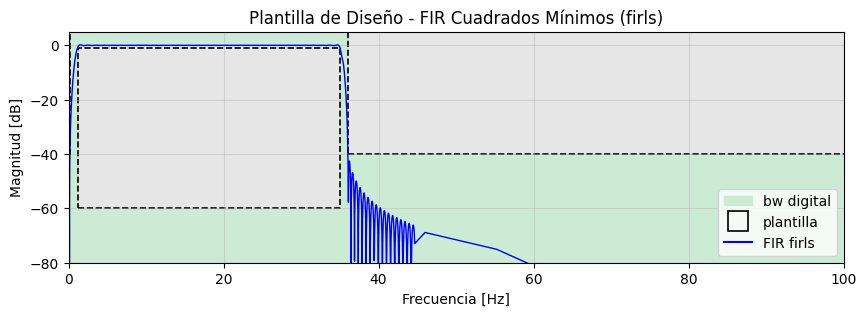

--- COMPARACIONES TEMPORALES: FIR CUADRADOS MÍNIMOS ---


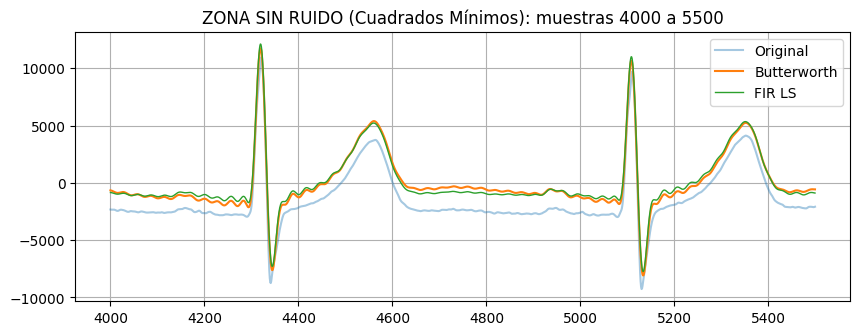

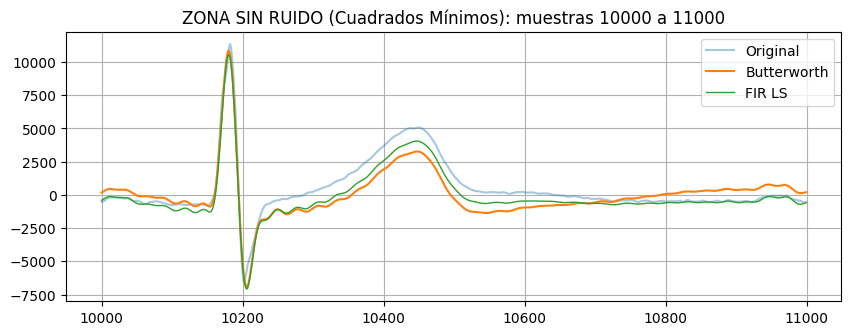

--- COMPARACIONES TEMPORALES: FIR CUADRADOS MÍNIMOS (ZONAS CON RUIDO) ---


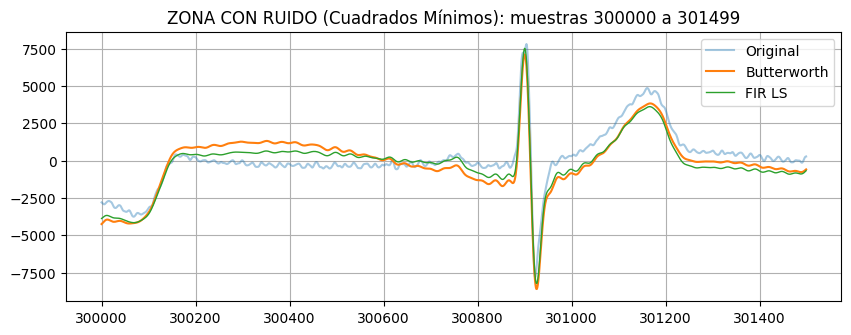

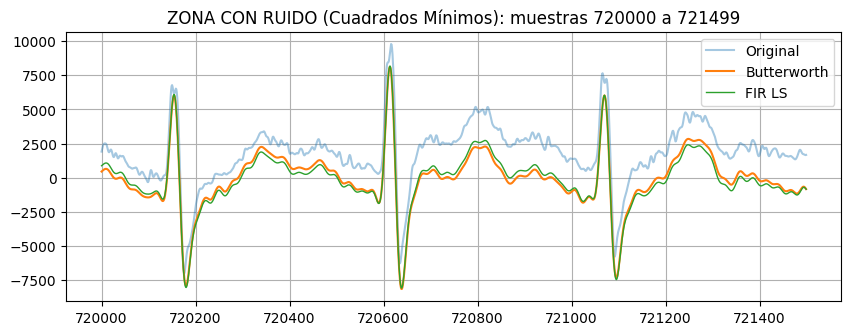

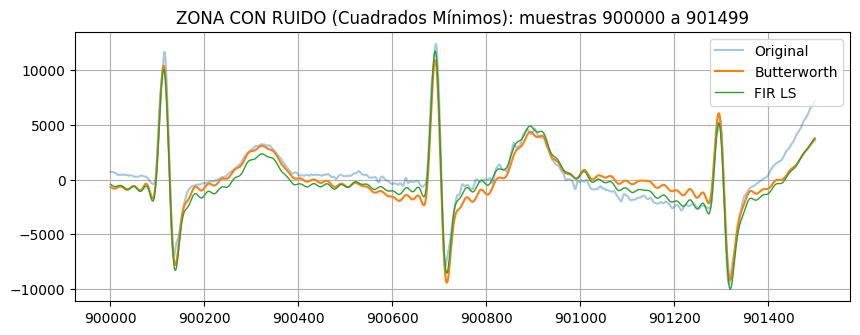

In [7]:
ws1_ls = 0.2 
wp1_ls = 1.2
wp2_ls = 35.0 
ws2_ls = 36.0 
numtaps_ls = 1851
gains_ls = [0, 0, 1, 1, 0, 0]
weight_ls = [20, 1, 7] 

b_ls = sig.firls(
    numtaps_ls,
    bands=[0, ws1_ls, wp1_ls, wp2_ls, ws2_ls, fs/2],
    desired=gains_ls,
    weight=weight_ls,
    fs=fs
)
ecg_fir_ls = sig.filtfilt(b_ls, 1, ecg_one_lead)

# --- Plantilla Espectral Cuadrados Mínimos ---
w, h = sig.freqz(b_ls, worN=ww, fs=fs)
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_facecolor('#ccebd5') 
ax.add_patch(patches.Rectangle((0, -gstop), ws1_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((wp1_teorica, -60), wp2_teorica - wp1_teorica, (-ripple) - (-60), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((ws2_teorica, -gstop), (fs/2) - ws2_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), color='blue', linewidth=1)
ax.set_title('Plantilla de Diseño - FIR Cuadrados Mínimos (firls)')
ax.set_xlabel('Frecuencia [Hz]'); ax.set_ylabel('Magnitud [dB]')
ax.grid(True, linestyle='-', alpha=0.4); ax.set_xlim([0, 100]); ax.set_ylim([-80, 5])
ax.legend(handles=[green_patch, dashed_line, mlines.Line2D([], [], color='blue', label='FIR firls')], loc='lower right')
plt.show()

# --- Gráficos Temporales ---
print("--- COMPARACIONES TEMPORALES: FIR CUADRADOS MÍNIMOS ---")
for reg in regs_sin_ruido:
    idx = np.arange(reg[0], reg[1])
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_fir_ls[idx], label='FIR LS', linewidth=1)
    plt.title(f'ZONA SIN RUIDO (Cuadrados Mínimos): muestras {reg[0]} a {reg[1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()
# --- Gráficos Temporales (Zonas CON Ruido) ---
print("--- COMPARACIONES TEMPORALES: FIR CUADRADOS MÍNIMOS (ZONAS CON RUIDO) ---")
for reg in regs_con_ruido:
    idx = np.arange(int(reg[0]), int(reg[0]) + 1500) # 1500 muestras para ver bien la morfología
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_fir_ls[idx], label='FIR LS', linewidth=1)
    plt.title(f'ZONA CON RUIDO (Cuadrados Mínimos): muestras {idx[0]} a {idx[-1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()

### Análisis
El método de cuadrados mínimos busca minimizar el error cuadrático medio entre la respuesta ideal y la obtenida.

Se observa una transición relativamente suave entre bandas y una buena preservación de las componentes útiles del ECG. La señal resultante presenta un adecuado nivel isoeléctrico y una reducción efectiva del ruido de alta frecuencia.

### Filtro Fir con Remez

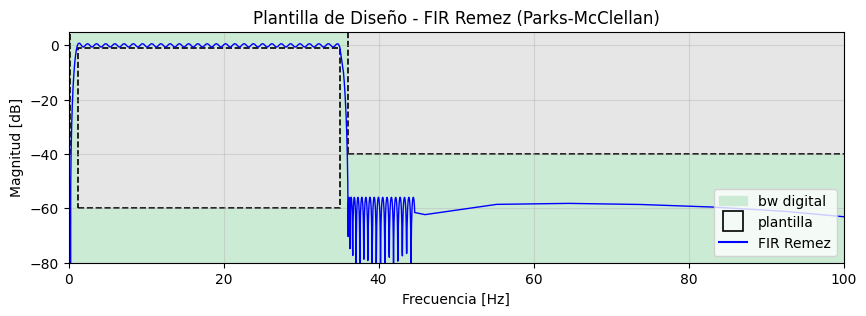

--- COMPARACIONES TEMPORALES: FIR REMEZ ---


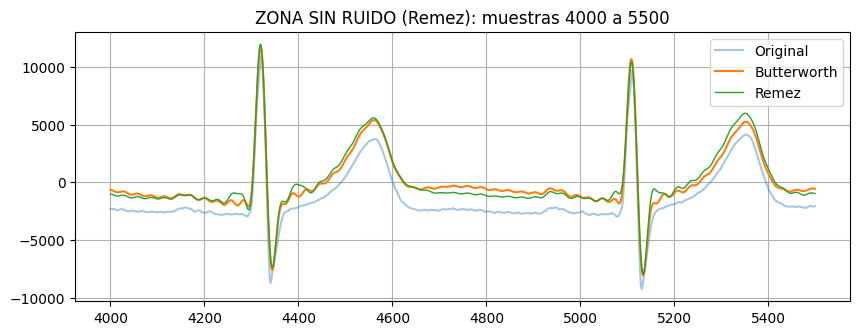

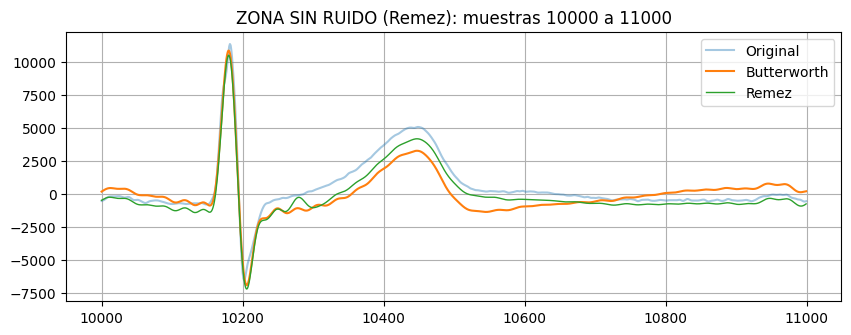

--- COMPARACIONES TEMPORALES: FIR REMEZ (ZONAS CON RUIDO) ---


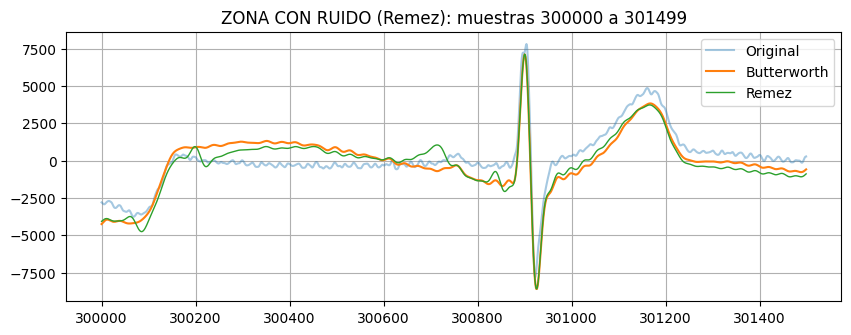

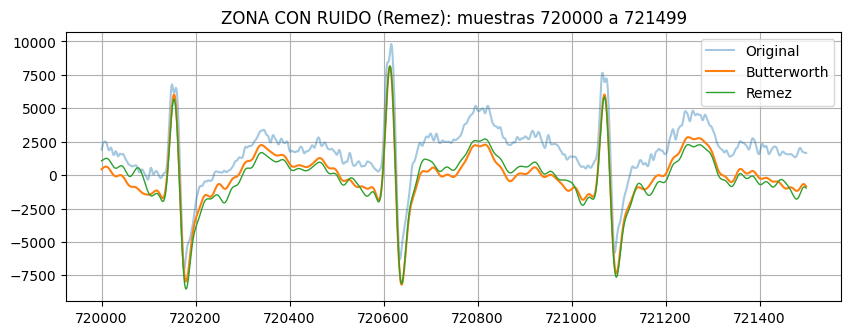

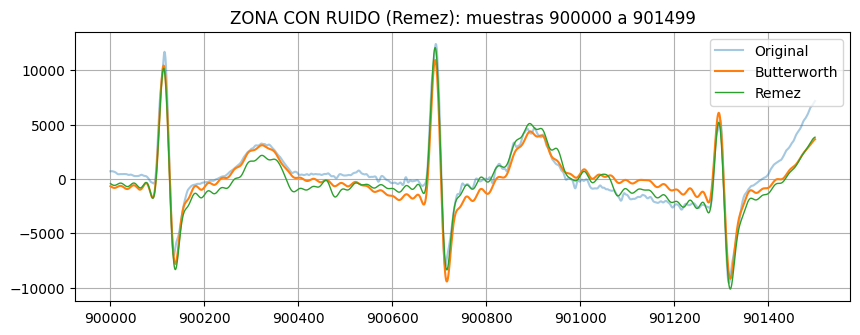

In [8]:
ws1_remez = 0.2
wp1_remez = 1.5 
wp2_remez = 35.0 
ws2_remez = 36.05 
numtaps_remez = 1721
gains_remez = [0, 1, 0] 
weight_remez = [40,1, 45] 

b_remez = sig.remez(
    numtaps_remez,
    bands=[0, ws1_remez, wp1_remez, wp2_remez, ws2_remez, fs/2],
    desired=gains_remez,
    weight=weight_remez,
    fs=fs,
    type='bandpass',
)
ecg_fir_remez = sig.filtfilt(b_remez, 1, ecg_one_lead)

# --- Plantilla Espectral Remez ---
w, h = sig.freqz(b_remez, worN=ww, fs=fs)
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_facecolor('#ccebd5') 
ax.add_patch(patches.Rectangle((0, -gstop), ws1_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((wp1_teorica, -60), wp2_teorica - wp1_teorica, (-ripple) - (-60), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.add_patch(patches.Rectangle((ws2_teorica, -gstop), (fs/2) - ws2_teorica, 5 - (-gstop), linewidth=1.2, edgecolor='black', linestyle='--', facecolor='#e6e6e6'))
ax.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), color='blue', linewidth=1)
ax.set_title('Plantilla de Diseño - FIR Remez (Parks-McClellan)')
ax.set_xlabel('Frecuencia [Hz]'); ax.set_ylabel('Magnitud [dB]')
ax.grid(True, linestyle='-', alpha=0.4); ax.set_xlim([0, 100]); ax.set_ylim([-80, 5])
ax.legend(handles=[green_patch, dashed_line, mlines.Line2D([], [], color='blue', label='FIR Remez')], loc='lower right')
plt.show()

# --- Gráficos Temporales ---
print("--- COMPARACIONES TEMPORALES: FIR REMEZ ---")
for reg in regs_sin_ruido:
    idx = np.arange(reg[0], reg[1])
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_fir_remez[idx], label='Remez', linewidth=1)
    plt.title(f'ZONA SIN RUIDO (Remez): muestras {reg[0]} a {reg[1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()
    # --- Gráficos Temporales (Zonas CON Ruido) ---
print("--- COMPARACIONES TEMPORALES: FIR REMEZ (ZONAS CON RUIDO) ---")
for reg in regs_con_ruido:
    idx = np.arange(int(reg[0]), int(reg[0]) + 1500)
    plt.figure(figsize=(10, 3.5))
    plt.plot(idx, ecg_one_lead[idx], label='Original', alpha=0.4)
    plt.plot(idx, ecg_butt[idx], label='Butterworth', linewidth=1.5)
    plt.plot(idx, ecg_fir_remez[idx], label='Remez', linewidth=1)
    plt.title(f'ZONA CON RUIDO (Remez): muestras {idx[0]} a {idx[-1]}')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()

### Análisis
En clase se sugirió utilizar un tipo 3 pero no logré que quedará coherente la plantilla por lo que opté por utilizar un tipo 1.
La plantilla de este filtro se obtuvo probando en clase diversos valores y encontrando cual se ajusta mejor, se fueron variando las bandas,el peso y la cantidad de coeficientes.  

Dicho esto, este filtro distribuye el error de aproximación uniformemente.

La respuesta que obtuve presenta transiciones más abruptas que los métodos anteriores, permitiendo cumplir la plantilla con una menor cantidad de coeficientes.
En la señal filtrada puedo observar que se eliminan las interferencias preservando la morfología original.


### Comparación de la PSD

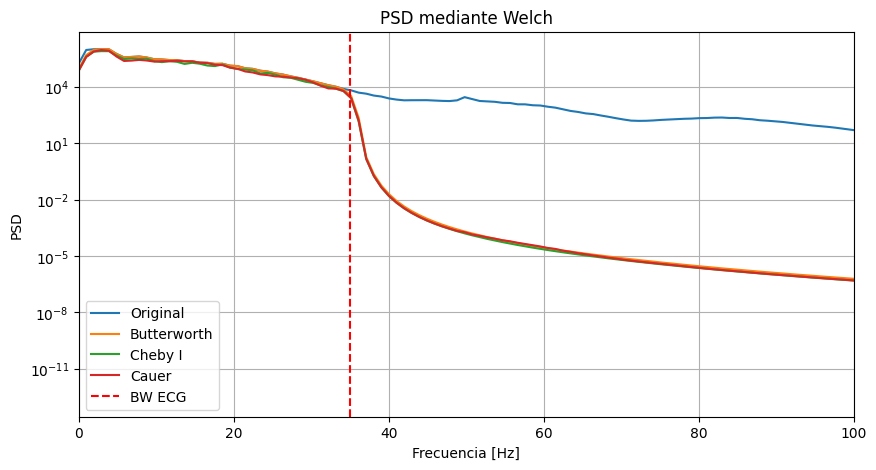

In [9]:
f, Pxx_orig = sig.welch(ecg_one_lead, fs=fs, nperseg=1024)
f, Pxx_butt = sig.welch(ecg_butt, fs=fs, nperseg=1024)
f, Pxx_cheby = sig.welch(ecg_cheby, fs=fs, nperseg=1024)
f, Pxx_cauer = sig.welch(ecg_cauer, fs=fs, nperseg=1024)

plt.figure(figsize=(10,5))

plt.semilogy(f, Pxx_orig, label='Original')
plt.semilogy(f, Pxx_butt, label='Butterworth')
plt.semilogy(f, Pxx_cheby, label='Cheby I')
plt.semilogy(f, Pxx_cauer, label='Cauer')

plt.axvline(35,color='red',linestyle='--',label='BW ECG')

plt.xlim([0,100])
plt.grid()
plt.legend()
plt.title('PSD mediante Welch')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.show()

### Comparación espectral mediante la PSD
La densidad espectral de potencia permite verificar la eliminación efectiva de las componentes fuera de la banda útil del ECG.

Se observa que todos los filtros reducen significativamente la energía presente por encima de 35 Hz, asociada principalmente al ruido muscular y al movimiento de electrodos. Asimismo, las componentes cercanas a continua son atenuadas, corrigiendo el desplazamiento de la línea de base.

Dentro de la banda útil, las PSD de las señales filtradas permanecen próximas a la señal original, indicando que la información fisiológica relevante fue preservada.

## Conclusiones
Se diseñaron y evaluaron distintos filtros FIR e IIR para el acondicionamiento de una señal ECG registrada durante una prueba de esfuerzo.

Todos los filtros desarrollados permitieron reducir las principales fuentes de contaminación presentes en el registro: movimiento de la línea de base, ruido muscular y artefactos generados por el movimiento de los electrodos.

El análisis temporal mostró que los complejos QRS conservan su forma característica luego del filtrado, mientras que el análisis espectral confirmó una fuerte atenuación de las componentes fuera de la banda útil del ECG.

En los filtros IIR los ordenes son para el Butter orden 348, el Cheby 1 orden 50 y Cauer orden 16, mientras que los filtros FIR los ordenes fueron mucho mayores, variando entre 1721 y 2000
Los filtros FIR ofrecen preservan la forma de onda a costa de una mayor complejidad computacional, mientras que los filtros IIR alcanzan resultados comparables utilizando órdenes mucho menores.

En función de la relación entre desempeño y complejidad, los filtros IIR resultan una alternativa muy eficiente para este tipo de aplicaciones biomédicas.